In [ ]:
"""
LEGACY FILE, this is only for reference on classification
"""


import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [ ]:
# ── Config ───────────────────────────────────────────────────────────────────
# Model trained on Ireland (5 classes: Excellent, Fair, Good, Marginal, Poor)
# Evaluated on China  (4 classes: Excellent, Fair, Good, Marginal — no Poor)
CHINA_PATH = "data/Dataset/Country-Wise Data/China_dataset.csv"
MODEL_PATH = "wqi_model.keras"
SCALER_PATH = "scaler.joblib"
LE_PATH = "label_encoder.joblib"
TARGET = "CCME_WQI"
FEATURES = [
    "Ammonia (mg/l)",
    "Biochemical Oxygen Demand (mg/l)",
    "Dissolved Oxygen (mg/l)",
    "Orthophosphate (mg/l)",
    "pH (ph units)",
    "Temperature (cel)",
    "Nitrogen (mg/l)",
    "Nitrate (mg/l)",
]


In [3]:
# ── 1. Load saved artifacts ──────────────────────────────────────────────────
model  = tf.keras.models.load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
le     = joblib.load(LE_PATH)
print(f"Model loaded — trained classes: {le.classes_}")

Model loaded — trained classes: ['Excellent' 'Fair' 'Good' 'Marginal' 'Poor']


In [ ]:
# ── 2. Load China data ───────────────────────────────────────────────────────
df_chn = pd.read_csv(CHINA_PATH)
print(f"China dataset: {df_chn.shape}")
print(f"\nClass distribution:")
print(df_chn[TARGET].value_counts())

# China has no 'Poor' samples - the model has a Poor output node but will
# never see a true Poor label here. Any Chinese sample predicted as Poor
# is a cross-region false positive, which we examine below.
X_chn = scaler.transform(df_chn[FEATURES].values)
y_chn = le.transform(df_chn[TARGET].values)   # encoded with Ireland's le
print(f"\nEncoded label set: {np.unique(y_chn)} → {le.inverse_transform(np.unique(y_chn))}")

China dataset: (45997, 14)

Class distribution:
CCME_WQI
Excellent    25116
Good         20424
Fair           336
Marginal       121
Name: count, dtype: int64

Encoded label set: [0 1 2 3] → ['Excellent' 'Fair' 'Good' 'Marginal']


In [5]:
# ── 3. Predict ───────────────────────────────────────────────────────────────
y_prob = model.predict(X_chn, verbose=0)   # shape (N, 5)
y_pred = np.argmax(y_prob, axis=1)

# How many China samples did the model predict as 'Poor'?
poor_idx = list(le.classes_).index("Poor")
n_pred_poor = (y_pred == poor_idx).sum()
print(f"China samples predicted as 'Poor' (false positives): {n_pred_poor} / {len(y_pred)}")

China samples predicted as 'Poor' (false positives): 0 / 45997


In [6]:
# ── 4. Overall metrics (China's 4 real classes only) ─────────────────────────
loss, acc = model.evaluate(X_chn, y_chn, verbose=0)
print(f"China — Accuracy : {acc:.4f}")
print(f"China — Loss     : {loss:.4f}\n")

china_classes = [c for c in le.classes_ if c != "Poor"]
print(classification_report(y_chn, y_pred, labels=le.transform(china_classes), target_names=china_classes))

China — Accuracy : 0.7567
China — Loss     : 0.5952

              precision    recall  f1-score   support

   Excellent       0.74      0.87      0.80     25116
        Fair       0.77      0.87      0.82       336
        Good       0.79      0.62      0.69     20424
    Marginal       1.00      0.52      0.68       121

    accuracy                           0.76     45997
   macro avg       0.82      0.72      0.75     45997
weighted avg       0.76      0.76      0.75     45997



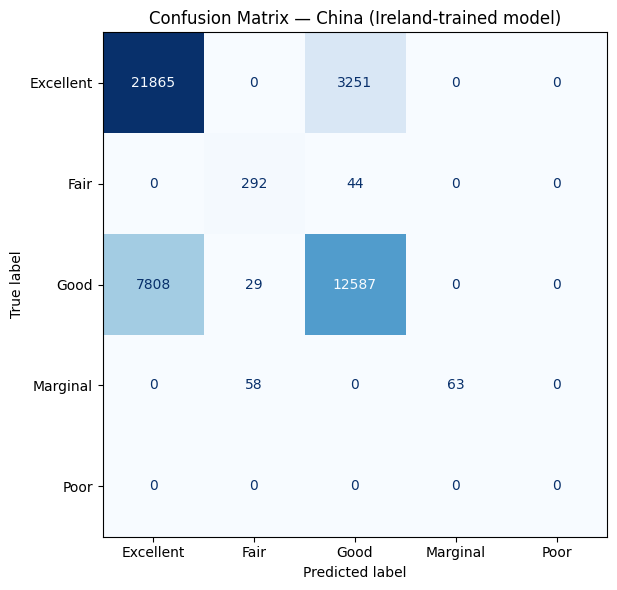

In [7]:
# ── 5. Plot 1 — Confusion matrix ─────────────────────────────────────────────
# Include Poor column to show any cross-region leakage
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_chn, y_pred, labels=range(len(le.classes_)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — China (Ireland-trained model)")
plt.tight_layout()
plt.savefig("china_confusion_matrix.png", dpi=150)
plt.show()

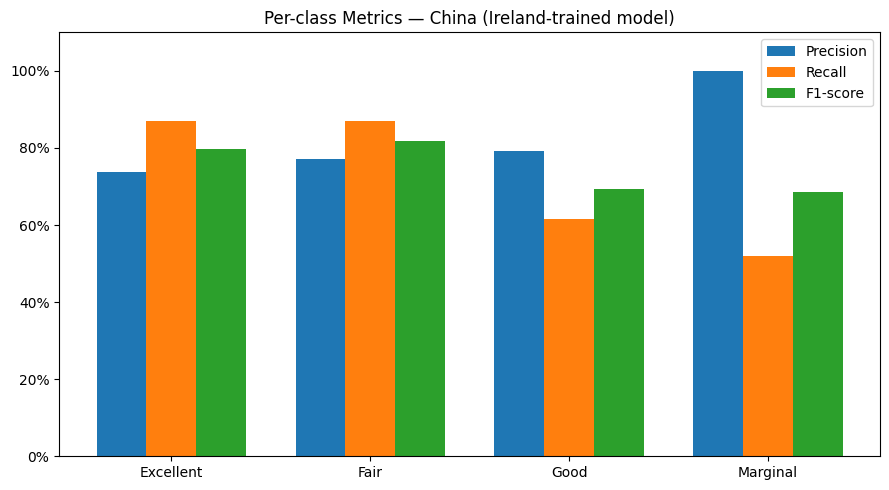

In [8]:
# ── 6. Plot 2 — Per-class F1 bar chart (China's 4 classes) ───────────────────
report_dict = classification_report(
    y_chn, y_pred,
    labels=le.transform(china_classes),
    target_names=china_classes,
    output_dict=True,
)
metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(china_classes))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(metrics):
    vals = [report_dict[cls][m] for cls in china_classes]
    ax.bar(x + i * width, vals, width, label=m.capitalize())

ax.set_xticks(x + width)
ax.set_xticklabels(china_classes)
ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Per-class Metrics — China (Ireland-trained model)")
ax.legend()
plt.tight_layout()
plt.savefig("china_per_class_metrics.png", dpi=150)
plt.show()

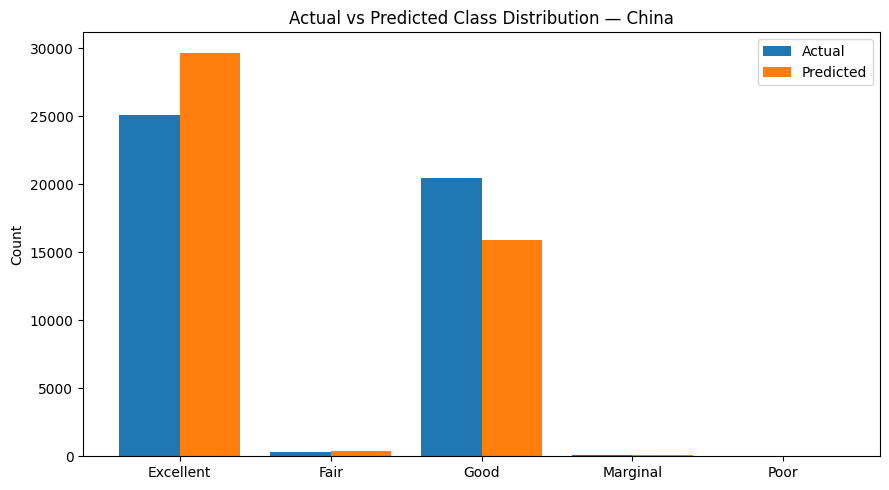

In [9]:
# ── 7. Plot 3 — Actual vs predicted class distribution ───────────────────────
actual_counts = pd.Series(le.inverse_transform(y_chn)).value_counts().reindex(le.classes_, fill_value=0)
pred_counts   = pd.Series(le.inverse_transform(y_pred)).value_counts().reindex(le.classes_, fill_value=0)

x_all = np.arange(len(le.classes_))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x_all - 0.2, actual_counts.values, 0.4, label="Actual")
ax.bar(x_all + 0.2, pred_counts.values,   0.4, label="Predicted")
ax.set_xticks(x_all)
ax.set_xticklabels(le.classes_)
ax.set_ylabel("Count")
ax.set_title("Actual vs Predicted Class Distribution — China")
ax.legend()
# Annotate the Poor bar to flag it
poor_pred = pred_counts["Poor"]
if poor_pred > 0:
    ax.annotate(f"{poor_pred} false\nPoor preds",
                xy=(poor_idx + 0.2, poor_pred),
                xytext=(poor_idx + 0.5, poor_pred + actual_counts.max() * 0.05),
                arrowprops=dict(arrowstyle="->"), fontsize=9, color="tomato")
plt.tight_layout()
plt.savefig("china_class_distribution.png", dpi=150)
plt.show()

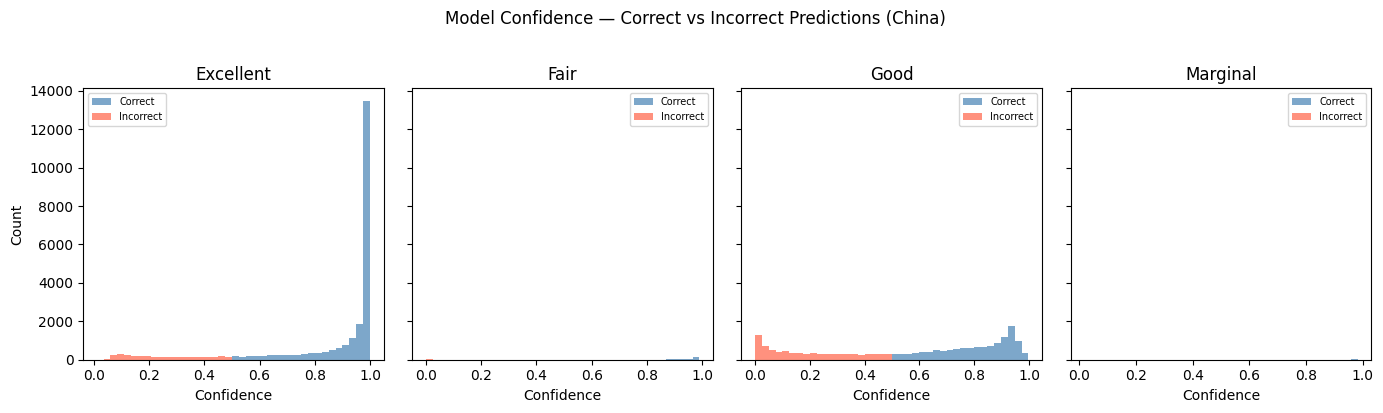

In [10]:
# ── 8. Plot 4 — Confidence distribution per true class ───────────────────────
fig, axes = plt.subplots(1, len(china_classes), figsize=(14, 4), sharey=True)
for i, cls in enumerate(china_classes):
    cls_idx = list(le.classes_).index(cls)
    mask = y_chn == cls_idx
    correct_conf   = y_prob[mask & (y_pred == y_chn), cls_idx]
    incorrect_conf = y_prob[mask & (y_pred != y_chn), cls_idx]
    axes[i].hist(correct_conf,   bins=20, alpha=0.7, label="Correct",   color="steelblue")
    axes[i].hist(incorrect_conf, bins=20, alpha=0.7, label="Incorrect", color="tomato")
    axes[i].set_title(cls)
    axes[i].set_xlabel("Confidence")
    if i == 0:
        axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=7)

fig.suptitle("Model Confidence — Correct vs Incorrect Predictions (China)", y=1.02)
plt.tight_layout()
plt.savefig("china_confidence.png", dpi=150)
plt.show()